[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nursnaaz/zero-to-genai-engineer/blob/main/10_RAG/notebooks/15_multimodal_rag_images.ipynb)

# Notebook 15 — Multimodal RAG: Teaching Your Chatbot to See

Notebook 13 built a production RAG chatbot — parse, chunk, hybrid retrieve, rerank, cite,
guard against hallucination, remember the conversation. It's genuinely production-shaped.

It's also **blind**. Real business documents — quarterly reports, academic theses, market
research — bury their most important findings inside charts. `PyMuPDF4LLMLoader`
(Notebook 02) extracts text beautifully. It throws every pixel of every image straight in
the trash.

**Today's document is real, not synthetic**: a 63-page university dissertation, *"Apple as
a Brand: A Detailed Analytical Approach"* (Christopher Odedina, April 2024), containing a
109-respondent Microsoft Forms survey. Chapter 4 alone embeds **21 real chart screenshots**
— bar charts, pie charts, and word clouds — and almost every interesting number in this
document (*"43 respondents have used Apple products for 5–10 years," "89 said Apple helps
them reach their goals," "78 respondents are aged 26–35"*) exists **only as pixels**. We
checked: none of those numbers appear anywhere in the extracted text.

**What you'll build today:**
1. Extract all 21 real embedded chart images out of this thesis
2. Caption them with a vision model so they become searchable
3. Index text chunks and image chunks **in the same hybrid retriever**, and prove retrieval
   actually discriminates between 21 different charts instead of just returning all of them
4. Ground the final answer on the **actual pixels**, not just a caption
5. Return **only the image(s) actually used**, not every chart in the corpus — verified
   across many real questions
6. **Build, not just describe**, all three multimodal RAG architectures the industry uses in
   2026 — caption-and-index, unified multimodal embeddings (CLIP), and page-as-image late
   interaction (the ColPali/ColQwen mechanism) — and honestly compare them on this same
   real, chart-heavy document

Everything here reuses the stack you already know: `text-embedding-3-small`, Chroma, BM25,
cross-encoder reranking, GPT-4o — plus, for architectures 2 and 3, a local CLIP model (no API
key, runs on CPU).

## 0. Install dependencies

In [1]:
# Install dependencies into the ACTIVE kernel (idempotent — skips what's already there).
%pip install -q \
    openai python-dotenv \
    pymupdf \
    langchain-community langchain-text-splitters langchain-pymupdf4llm pypdf \
    sentence-transformers bm25s PyStemmer chromadb \
    torch transformers \
    matplotlib pillow numpy
print("Dependencies ready.")



[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: /Users/mohamednoordeenalaudeen/Documents/GenAI-2026/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Dependencies ready.


## 1. Setup

Same pattern as every notebook since 01: load the API key from `10_RAG/.env`, quiet down the
noisy library loggers, and point at the shared `notebooks/data/` folder.

In [2]:
import warnings, os, sys, base64, uuid, re
warnings.filterwarnings("ignore")
import logging
for _n in ("httpx", "openai", "httpcore", "sentence_transformers", "transformers", "chromadb"):
    logging.getLogger(_n).setLevel(logging.ERROR)

from pathlib import Path
from dotenv import load_dotenv
from IPython.display import display, Image as IPyImage, Markdown
import numpy as np

NOTEBOOK_DIR = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd() / "10_RAG" / "notebooks"
DATA = NOTEBOOK_DIR / "data"
load_dotenv(NOTEBOOK_DIR.parent / ".env")

from openai import OpenAI
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

CHAT_MODEL = "gpt-4o"                    # vision-capable — needed for both captioning and generation
EMBED_MODEL = "text-embedding-3-small"

print("Setup complete. Data folder:", DATA)


Setup complete. Data folder: /Users/mohamednoordeenalaudeen/Documents/GenAI-2026/zero-to-genai-engineer/10_RAG/notebooks/data


## 2. The cold open — watch a text-only RAG go blind (or worse, get misled)

`apple_brand_analysis_report.pdf` is a real 63-page dissertation analyzing Apple's brand
positioning, built around a 109-respondent survey. Chapter 4 presents each survey question as
a numbered chart ("Chart 4.1", "Chart 4.2", ...) — a Microsoft Forms screenshot embedded
directly in the Word document, followed by a paragraph of commentary.

This isn't a synthetic example built to make a point — it's a genuine property of this real
document, found by checking it: the author's own prose analysis of Chart 4.1 states *"46 out
of 121"* respondents have used Apple products for 5–10 years. The chart itself, the original
data, shows **43** (and its six categories sum to 108, not 121). Real dissertations get copy
edited; numbers drift between a chart and the paragraph written about it. A text-only RAG has
no way to know that — depending on exactly which chunks its retrieval happens to surface, it
will either shrug and say the number isn't available, or confidently repeat whichever of the
two conflicting numbers it found. Neither is the real answer. Let's watch, then see whether
grounding on the actual chart pixels fixes it.

In [3]:
from langchain_pymupdf4llm import PyMuPDF4LLMLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

SAMPLE_PDF = DATA / "apple_brand_analysis_report.pdf"

# Text-only load, exactly like Notebook 13.
text_docs = PyMuPDF4LLMLoader(str(SAMPLE_PDF), use_ocr=False).load()
splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=100)
text_only_chunks = [c.page_content for d in text_docs for c in splitter.create_documents([d.page_content])]

print(f"Text-only pipeline extracted {len(text_only_chunks)} chunks from all 63 pages. Zero images.\n")

def embed(texts: list[str]) -> np.ndarray:
    resp = client.embeddings.create(model=EMBED_MODEL, input=texts)
    return np.array([d.embedding for d in resp.data])

chunk_vecs = embed(text_only_chunks)

def top_k_text_only(question: str, k: int = 4) -> list[str]:
    qvec = embed([question])[0]
    sims = chunk_vecs @ qvec / (np.linalg.norm(chunk_vecs, axis=1) * np.linalg.norm(qvec))
    top_idx = np.argsort(-sims)[:k]
    return [text_only_chunks[i] for i in top_idx]

COLD_OPEN_QUESTION = "What is the exact bar chart breakdown of how long respondents have owned Apple products?"

context = "\n\n".join(top_k_text_only(COLD_OPEN_QUESTION))
cold_open_resp = client.chat.completions.create(
    model=CHAT_MODEL,
    temperature=0,
    messages=[
        {"role": "system", "content": "Answer ONLY from the provided context. If the exact numbers aren't there, say so plainly."},
        {"role": "user", "content": f"Context:\n{context}\n\nQuestion: {COLD_OPEN_QUESTION}"},
    ],
)
text_only_answer = cold_open_resp.choices[0].message.content
print("Q:", COLD_OPEN_QUESTION)
print("\nText-only answer:\n", text_only_answer)

if "46" in text_only_answer:
    verdict = "It confidently repeated the document's OWN inconsistent prose figure (46) — wrong."
elif "43" in text_only_answer:
    verdict = "It happened to land on 43 from text alone this run — but that's luck, not grounding: rerun this cell and it can just as easily surface the conflicting '46' text chunk instead."
else:
    verdict = "It couldn't find a confident number in the retrieved text chunks at all — blind."
print(f"\n({verdict}")
print(" The chart itself — the original data — shows 43 for '5-10 years,' across six categories")
print(" that sum to 108. The paragraph analyzing it separately says '46 out of 121.' Only reading")
print(" the actual chart pixels resolves which one is real. Let's see what happens next.)")


Text-only pipeline extracted 231 chunks from all 63 pages. Zero images.



Q: What is the exact bar chart breakdown of how long respondents have owned Apple products?

Text-only answer:
 The exact bar chart breakdown of how long respondents have owned Apple products is not provided in the context.

(It couldn't find a confident number in the retrieved text chunks at all — blind.
 The chart itself — the original data — shows 43 for '5-10 years,' across six categories
 that sum to 108. The paragraph analyzing it separately says '46 out of 121.' Only reading
 the actual chart pixels resolves which one is real. Let's see what happens next.)


## 3. Extracting all 21 real chart images from the thesis

`fitz` (PyMuPDF's Python binding) walks every page and pulls out every embedded raster image
with `page.get_images()` + `doc.extract_image(xref)` — real, actual pixels, the same bytes
Word embedded when the author pasted each Microsoft Forms screenshot in. We filter out a
handful of tiny 17×17 decorative icons (dropdown-arrow artifacts from the Word export) that
aren't real chart content — anything under 100×100 pixels is noise, not a chart.

Extracted 21 real chart images (PyMuPDF4LLMLoader extracted 0).



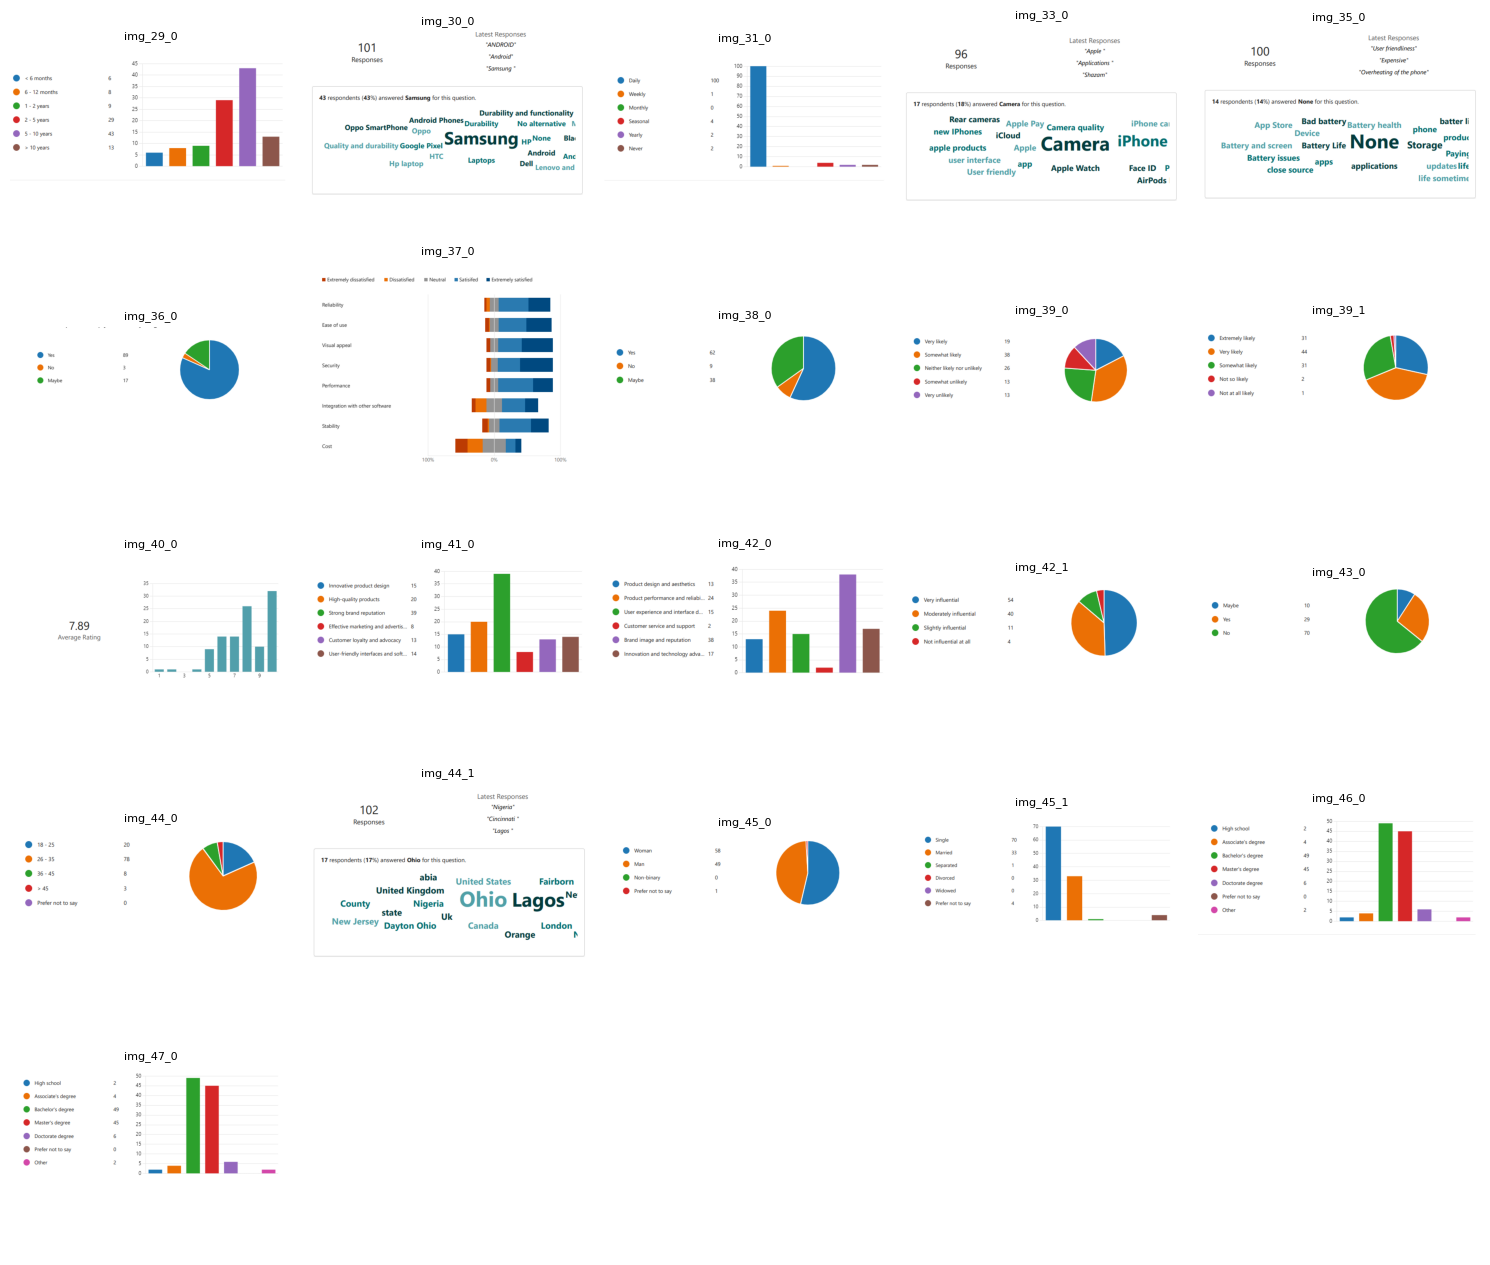

In [4]:
import fitz  # PyMuPDF
import matplotlib.pyplot as plt
from PIL import Image as PILImage

def extract_images_from_pdf(pdf_path: Path) -> list[dict]:
    """Returns [{id, page, bytes, ext, path}] for every real embedded chart image
    (tiny decorative icons under 100x100px are filtered out as noise, not content)."""
    doc = fitz.open(str(pdf_path))
    out_dir = DATA / "_extracted_images"
    out_dir.mkdir(exist_ok=True)
    images = []
    for page_num in range(len(doc)):
        for img_index, img in enumerate(doc[page_num].get_images(full=True)):
            xref = img[0]
            base = doc.extract_image(xref)
            if base["width"] < 100 or base["height"] < 100:
                continue
            image_id = f"img_{page_num}_{img_index}"
            path = out_dir / f"{image_id}.{base['ext']}"
            path.write_bytes(base["image"])
            images.append({"id": image_id, "page": page_num, "bytes": base["image"], "ext": base["ext"], "path": path})
    doc.close()
    return images

extracted_images = extract_images_from_pdf(SAMPLE_PDF)
print(f"Extracted {len(extracted_images)} real chart images (PyMuPDF4LLMLoader extracted 0).\n")

def show_images_row(items: list[tuple], suptitle: str | None = None, width_per_image: float = 2.6):
    """items: list of (image_path, caption_str) — renders them side by side, actual pixels, not just filenames."""
    n = len(items)
    fig, axes = plt.subplots(1, n, figsize=(width_per_image * n, width_per_image + 0.9))
    axes = [axes] if n == 1 else list(axes)
    for ax, (path, caption) in zip(axes, items):
        ax.imshow(PILImage.open(path))
        ax.set_title(caption, fontsize=9, wrap=True)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=12, y=1.06)
    plt.tight_layout()
    plt.show()

fig, axes = plt.subplots(5, 5, figsize=(15, 13))
for ax, img in zip(axes.flat, extracted_images):
    ax.imshow(PILImage.open(img["path"]))
    ax.set_title(img["id"], fontsize=8)
    ax.axis("off")
for ax in axes.flat[len(extracted_images):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


## 4. Three ways to make images searchable — we're building all three today

An embedding model can't search raw image bytes unless you pick one of three real
architectures. As of 2026, the market has converged on exactly these three, and unlike most
tutorials, this notebook actually **builds and runs all three** against the same real
21-chart document, not just describes them:

| # | Architecture | How it works | Best for | Tradeoff |
|---|---|---|---|---|
| **1** | **Caption-and-index** (Sections 5–13) | A vision LLM writes a detailed text caption of each image (chart title, axis labels, exact values); embed the *caption*; keep the raw image linked by ID | Reads the exact numbers off charts correctly — the practical default for business/report documents | An extra LLM call per image; "caption drift" if generation isn't also grounded on real pixels |
| **2** | **Unified multimodal embeddings** (Section 14) | One model (CLIP here; Cohere Embed-v4/Voyage multimodal-3.5/Gemini Embedding 2 in production) embeds *both* text and images into the *same* space — no captioning step at all | Distinguishing genuinely different visual content, zero LLM calls | You'll see it honestly struggle on THIS document, where every image is a similarly-shaped chart screenshot |
| **3** | **Page-as-image, late interaction** (Section 15) | Skip parsing — embed the image at **patch level** (dozens of small regions, not one pooled vector), score with MaxSim (ColBERT-style). ColPali/ColQwen2.5/3 do this with a purpose-built vision-language backbone at real document scale | Visually dense documents where fine-grained layout matters | Heavier infra in production; here we build the same *mechanism* at toy scale with CLIP's own patch tokens |

We start with architecture 1 because it's the one that reuses everything you already built in
Notebook 13 unchanged, and — as you'll see by Section 15 — it's also the one best suited to a
document like this one, where 21 images all share the same "legend + chart" visual template.

## 5. Captioning images with GPT-4o Vision — making pixels searchable text

Base64-encode the image bytes and pass them as an `image_url` content block with a `data:`
URI. The prompt asks for **only what's literally visible** — the chart title, every
axis/legend label, and every exact number. A vague prompt ("describe this image") invites the
model to editorialize; a specific one keeps it grounded and gives us much better search text.

Captioning all 21 images takes a little while — we print the first few so you can see the
quality, then the rest run quietly.

In [5]:
CAPTION_PROMPT = (
    "Describe this image factually and thoroughly, in 2-4 sentences. If it is a chart or "
    "graph, state the title, every axis/category label, and every exact numeric value or "
    "percentage visible. If it is a word cloud, state the title/question if visible and list "
    "the most prominent words. Do not interpret or editorialize — only state what is "
    "literally shown. This will be used to power search, so be specific."
)

def caption_image(image_bytes: bytes, ext: str) -> str:
    b64 = base64.b64encode(image_bytes).decode()
    resp = client.chat.completions.create(
        model=CHAT_MODEL,
        temperature=0,   # deterministic reads of a chart's numbers matter more than creative variety here
        messages=[{
            "role": "user",
            "content": [
                {"type": "text", "text": CAPTION_PROMPT},
                {"type": "image_url", "image_url": {"url": f"data:image/{ext};base64,{b64}", "detail": "high"}},
            ],
        }],
    )
    return resp.choices[0].message.content

for i, img in enumerate(extracted_images):
    img["caption"] = caption_image(img["bytes"], img["ext"])
    if i < 4:
        print(f"--- {img['id']} (page {img['page'] + 1}) ---")
        print(img["caption"])
        print()

print(f"... captioned all {len(extracted_images)} images. Two examples from later in the run:\n")
for img in extracted_images[10:12]:
    print(f"--- {img['id']} (page {img['page'] + 1}) ---")
    print(img["caption"])
    print()


--- img_29_0 (page 30) ---
The image is a bar chart with no title visible. It displays six categories on the x-axis, each represented by a different color: blue for "< 6 months," orange for "6 - 12 months," green for "1 - 2 years," red for "2 - 5 years," purple for "5 - 10 years," and brown for "> 10 years." The y-axis ranges from 0 to 45. The exact numeric values for each category are: "< 6 months" is 6, "6 - 12 months" is 8, "1 - 2 years" is 9, "2 - 5 years" is 29, "5 - 10 years" is 43, and "> 10 years" is 13.



--- img_30_0 (page 31) ---
The image shows a word cloud with the most prominent word being "Samsung." Other visible words include "Oppo SmartPhone," "Android Phones," "Durability," "Quality and durability," "Google Pixel," "HTC," "Hp laptop," "Laptops," "No alternative," "HP," "None," "Android," "Dell," and "Lenovo and." Above the word cloud, it states "101 Responses" and "Latest Responses" with entries: "ANDROID," "Android," and "Samsung." Additionally, it notes that "43 respondents (43%) answered Samsung for this question."



--- img_31_0 (page 32) ---
The image is a bar chart with categories labeled as Daily, Weekly, Monthly, Seasonal, Yearly, and Never. The numeric values for each category are: Daily (100), Weekly (1), Monthly (0), Seasonal (4), Yearly (2), and Never (2). The y-axis ranges from 0 to 100. Each category is represented by a different color: Daily (blue), Weekly (orange), Monthly (green), Seasonal (red), Yearly (purple), and Never (brown).



--- img_33_0 (page 34) ---
The image shows a word cloud with the most prominent words being "Camera" and "iPhone." Other visible words include "Rear cameras," "Apple Pay," "Camera quality," "new iPhones," "iCloud," "Apple Watch," "Face ID," "AirPods," "apple products," "user interface," "User friendly," and "app." Above the word cloud, it states "96 Responses" and "Latest Responses" with the entries "Apple," "Applications," and "Shazam." Additionally, it notes that "17 respondents (18%) answered Camera for this question."



... captioned all 21 images. Two examples from later in the run:

--- img_40_0 (page 41) ---
The image shows a bar chart with the title "Average Rating" and a numeric value of 7.89. The x-axis is labeled with numbers 1 through 9, representing rating scores. The y-axis is labeled with numbers from 0 to 35, indicating frequency. The bars show the following frequencies for each rating: 1 (1), 3 (1), 5 (9), 7 (15), 9 (32).

--- img_41_0 (page 42) ---
The image is a bar chart with six categories, each represented by a different color. The categories are: "Innovative product design" (blue) with a value of 15, "High-quality products" (orange) with a value of 20, "Strong brand reputation" (green) with a value of 39, "Effective marketing and advertising" (red) with a value of 8, "Customer loyalty and advocacy" (purple) with a value of 13, and "User-friendly interfaces and software" (brown) with a value of 14. The vertical axis ranges from 0 to 40.



## 6. The multi-vector pattern — decoupling what you search from what you return

A vector index needs *searchable text*. A user answer needs the *real content*. For an image
chunk those are two different things:

- **What you search on** → the caption ("Chart 4.15. How old are you? Pie chart: 18-25=20,
  26-35=78, ...")
- **What you return / ground generation on** → the actual chart image bytes

LangChain calls this the **multi-vector retriever** pattern: a `docstore` (id → raw content,
text *or* image) separate from the `vector store` (id → embedding of the *searchable*
representation). Retrieval searches the vector store; once you have the winning IDs, you look
up the real content in the docstore.

In [6]:
from dataclasses import dataclass

@dataclass
class MultimodalChunk:
    id: str
    kind: str              # "text" | "image"
    searchable_text: str    # what gets embedded / BM25-indexed
    source: str
    page: int
    image_path: Path | None = None   # populated only for kind == "image"

chunks: list[MultimodalChunk] = []

for d in text_docs:
    for piece in splitter.split_text(d.page_content):
        chunks.append(MultimodalChunk(
            id=str(uuid.uuid4()), kind="text", searchable_text=piece,
            source=SAMPLE_PDF.name, page=d.metadata.get("page", 0),
        ))

for img in extracted_images:
    chunks.append(MultimodalChunk(
        id=img["id"], kind="image", searchable_text=img["caption"],
        source=SAMPLE_PDF.name, page=img["page"], image_path=img["path"],
    ))

n_text = sum(1 for c in chunks if c.kind == "text")
n_img = sum(1 for c in chunks if c.kind == "image")
print(f"Combined pool: {n_text} text chunks + {n_img} image chunks = {len(chunks)} total, one index.")
print("This is a real-scale corpus, not a toy — 21 visually similar charts genuinely need to")
print("be told apart, not just the whole set returned every time.")


Combined pool: 231 text chunks + 21 image chunks = 252 total, one index.
This is a real-scale corpus, not a toy — 21 visually similar charts genuinely need to
be told apart, not just the whole set returned every time.


## 7. Building the hybrid multimodal index (dense + sparse, Notebooks 04–07)

No new retrieval machinery — dense (Chroma) + sparse (BM25) + RRF fusion, exactly as in
Notebooks 05–07 and the production pipeline in `rag_pipeline.py`. The index has no idea it's
holding a mix of modalities.

In [7]:
import chromadb
import bm25s
from Stemmer import Stemmer

text_chunks = [c for c in chunks if c.kind == "text"]
image_chunks = [c for c in chunks if c.kind == "image"]

chroma_client = chromadb.EphemeralClient()
collection = chroma_client.get_or_create_collection("multimodal_demo")
text_vecs = embed([c.searchable_text for c in text_chunks])
collection.add(
    ids=[c.id for c in text_chunks],
    embeddings=[v.tolist() for v in text_vecs],
    documents=[c.searchable_text for c in text_chunks],
)

# Image captions get their own embedding matrix, kept separate from the text index —
# Section 8 explains exactly why this separation matters.
image_vecs = embed([c.searchable_text for c in image_chunks])

stemmer = Stemmer("english")
def bm25_tokenize(texts):
    return bm25s.tokenize(texts, stopwords="en", stemmer=stemmer.stemWords, return_ids=False, show_progress=False)

bm25_index = bm25s.BM25(method="lucene")
bm25_index.index(bm25_tokenize([c.searchable_text for c in text_chunks]), show_progress=False)

chunks_by_id = {c.id: c for c in chunks}
text_by_id = {c.id: c for c in text_chunks}
print(f"Indexed {len(text_chunks)} text chunks into Chroma (dense) + BM25 (sparse), "
      f"and {len(image_chunks)} image captions into their own embedding matrix.")


Indexed 231 text chunks into Chroma (dense) + BM25 (sparse), and 21 image captions into their own embedding matrix.


## 8. Retrieval + reranking — proving 21 charts actually get discriminated

The obvious first design is one unified ranking: dense + BM25 fusion over all 252 chunks, then
a single cross-encoder reranker picks the winners — text and image captions competing head to
head. Checking that design's actual scores against a known-correct answer exposes a real bug:
the reranker (trained on natural prose passages) consistently rates a chart's terse caption
*below* flowing analysis paragraphs that merely discuss the same topic without the exact
number. Watch it happen:

In [8]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def unified_rerank_only(question: str, pool: int = 15):
    """The naive version: text and image captions compete in ONE reranked list."""
    qvec = embed([question])[0]
    dense_ids = collection.query(query_embeddings=[qvec.tolist()], n_results=pool)["ids"][0]
    bm25_scores = bm25_index.get_scores(bm25_tokenize([question])[0])
    sparse_ids = [text_chunks[i].id for i in np.argsort(-bm25_scores)[:pool]]
    scores = {}
    for rank, cid in enumerate(dense_ids): scores[cid] = scores.get(cid, 0) + 1 / (60 + rank + 1)
    for rank, cid in enumerate(sparse_ids): scores[cid] = scores.get(cid, 0) + 1 / (60 + rank + 1)
    text_candidate_ids = set(sorted(scores, key=scores.get, reverse=True)[:pool])
    # give every image a chance to compete too, purely so we can show the reranker burying it
    img_sims_all = image_vecs @ qvec / (np.linalg.norm(image_vecs, axis=1) * np.linalg.norm(qvec))
    top_img_ids = {image_chunks[i].id for i in np.argsort(-img_sims_all)[:5]}
    # .get(...) + filter, not text_by_id[cid]: if you re-ran an earlier cell (fresh chunk
    # IDs) without re-running this cell right after, some retrieved IDs may be stale — skip
    # them instead of crashing.
    candidates = [text_by_id[cid] for cid in text_candidate_ids if cid in text_by_id] +         [c for c in image_chunks if c.id in top_img_ids]
    pairs = [[question, c.searchable_text] for c in candidates]
    rr = reranker.predict(pairs)
    return sorted(zip(rr, candidates), key=lambda x: -x[0])

demo_q = "What percentage of respondents considered Samsung as an alternative before buying an Apple product?"
print(f'Unified reranking for: "{demo_q}"\n')
for score, c in unified_rerank_only(demo_q)[:8]:
    marker = "  <-- has the real 43% answer" if c.id == "img_30_0" else ""
    print(f"  {score:+.2f}  [{c.kind:5}]  {c.searchable_text[:55]}...{marker}")
print("\nThe chart with the actual answer (43%) gets buried outside the top 6 — a general-")
print("purpose text reranker just doesn't rate a caption's plain data listing as highly as a")
print("prose paragraph that merely *talks about* the same topic without the exact number.")


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Unified reranking for: "What percentage of respondents considered Samsung as an alternative before buying an Apple product?"



  +5.06  [text ]  **Customer Loyalty and Satisfaction:** The majority of ...
  +4.48  [text ]  Samsung emerges as a significant competitor, highlighti...
  +3.92  [text ]  31 



# **Chart 4.2. What alternatives did you conside...
  +1.85  [text ]  _This work employs a survey design to investigate the g...
  +0.46  [text ]  _The work draw the following conclusions; Long-term usa...
  -0.73  [text ]  44 

# **Chart 4.13. How influential are factors like b...
  -0.80  [text ]  The significant number of respondents who did not consi...
  -0.84  [image]  The image shows a word cloud with the most prominent wo...  <-- has the real 43% answer

The chart with the actual answer (43%) gets buried outside the top 6 — a general-
purpose text reranker just doesn't rate a caption's plain data listing as highly as a
prose paragraph that merely *talks about* the same topic without the exact number.


### The fix: score each modality on its own terms, then merge

Don't force text and image captions into one ranking that structurally favors prose. Rerank
text candidates among themselves (that's what the reranker is actually good at), and let
images compete in their **own** dedicated ranking by embedding similarity — guaranteeing the
most relevant charts always reach the final context instead of getting crowded out by
unrelated prose. This isn't a hack: production multimodal RAG systems commonly score
modalities separately for exactly this reason, then merge before generation.

In [9]:
def hybrid_retrieve(question: str, n_text: int = 4, n_images: int = 3, pool: int = 12,
                     rrf_k: int = 60, verbose: bool = False) -> list[MultimodalChunk]:
    qvec = embed([question])[0]

    # TEXT: RRF(dense, sparse) then cross-encoder rerank, exactly as before — just text-only now.
    dense_ids = collection.query(query_embeddings=[qvec.tolist()], n_results=pool)["ids"][0]
    bm25_scores = bm25_index.get_scores(bm25_tokenize([question])[0])
    sparse_ids = [text_chunks[i].id for i in np.argsort(-bm25_scores)[:pool]]
    scores = {}
    for rank, cid in enumerate(dense_ids): scores[cid] = scores.get(cid, 0) + 1 / (rrf_k + rank + 1)
    for rank, cid in enumerate(sparse_ids): scores[cid] = scores.get(cid, 0) + 1 / (rrf_k + rank + 1)
    text_candidates = [text_by_id[cid] for cid in sorted(scores, key=scores.get, reverse=True)[:pool] if cid in text_by_id]
    pairs = [[question, c.searchable_text] for c in text_candidates]
    rr = reranker.predict(pairs)
    top_text = [c for _, c in sorted(zip(rr, text_candidates), key=lambda x: -x[0])[:n_text]]

    # IMAGES: their own dedicated ranking, by pure embedding cosine similarity — never
    # arbitrated against text by the (text-biased) cross-encoder.
    img_sims = image_vecs @ qvec / (np.linalg.norm(image_vecs, axis=1) * np.linalg.norm(qvec))
    top_img_order = np.argsort(-img_sims)[:n_images]
    top_images = [image_chunks[i] for i in top_img_order]

    if verbose:
        print(f'Text candidates for: "{question}"')
        for score, c in sorted(zip(rr, text_candidates), key=lambda x: -x[0])[:n_text]:
            print(f"  {score:+.2f}  {c.searchable_text[:65]}...")
        print(f'\nImage candidates for: "{question}"')
        for i in top_img_order:
            print(f"  sim={float(img_sims[i]):.3f}  {image_chunks[i].id}  {image_chunks[i].searchable_text[:55]}...")

    return top_text + top_images

_ = hybrid_retrieve(demo_q, verbose=True)


Text candidates for: "What percentage of respondents considered Samsung as an alternative before buying an Apple product?"
  +5.06  **Customer Loyalty and Satisfaction:** The majority of respondent...
  +4.48  Samsung emerges as a significant competitor, highlighting the imp...
  +3.92  31 



# **Chart 4.2. What alternatives did you consider before p...
  +1.85  _This work employs a survey design to investigate the growth and ...

Image candidates for: "What percentage of respondents considered Samsung as an alternative before buying an Apple product?"
  sim=0.534  img_30_0  The image shows a word cloud with the most prominent wo...
  sim=0.453  img_33_0  The image shows a word cloud with the most prominent wo...
  sim=0.428  img_35_0  The image shows a word cloud with the most prominent wo...


## 9. Vision-grounded generation, with citation tracking

At generation time, for any image chunk, we send GPT-4o the actual image bytes, not the
caption — the model reads the real pixels instead of trusting a caption that might have
drifted. We also parse **which sources the model actually cited** — `[1]`, `[2]`, etc. — so
the next section can show back only the chart(s) genuinely used in the answer, not every
chart that happened to be in the retrieved set.

In [10]:
def generate_multimodal_answer(question: str, retrieved: list[MultimodalChunk]) -> tuple[str, set[int]]:
    content_blocks = [{"type": "text", "text":
        "Answer the question using ONLY the sources below. Cite each source you actually use "
        "inline as [1], [2], etc. — do not cite a source you didn't use. For any number that "
        "comes from a chart image, read it directly off the image pixels — the image is the "
        "ground truth. If a text source states a different number than what a chart image "
        "shows for the same fact, trust the chart image: text commentary can contain "
        "transcription errors, but the chart is the original data. If the answer isn't in the "
        "sources, say so.\n\n"
        f"Question: {question}\n\nSources:"}]

    for i, chunk in enumerate(retrieved, start=1):
        if chunk.kind == "text":
            content_blocks.append({"type": "text", "text": f"\n[{i}] (text, page {chunk.page}): {chunk.searchable_text}"})
        else:
            b64 = base64.b64encode(chunk.image_path.read_bytes()).decode()
            content_blocks.append({"type": "text", "text": f"\n[{i}] (chart image, page {chunk.page}):"})
            content_blocks.append({"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64}", "detail": "high"}})

    resp = client.chat.completions.create(model=CHAT_MODEL, temperature=0, messages=[{"role": "user", "content": content_blocks}])
    answer = resp.choices[0].message.content
    cited_indices = {int(n) for n in re.findall(r"\[(\d+)\]", answer)}
    return answer, cited_indices

answer, cited = generate_multimodal_answer(COLD_OPEN_QUESTION, hybrid_retrieve(COLD_OPEN_QUESTION))
print("Multimodal answer:\n")
print(answer)
print("\nActually cited source indices:", cited)


Multimodal answer:

The exact bar chart breakdown of how long respondents have owned Apple products is as follows:

- < 6 months: 6
- 6 - 12 months: 8
- 1 - 2 years: 9
- 2 - 5 years: 29
- 5 - 10 years: 43
- > 10 years: 13

[5]

Actually cited source indices: {5}


## 10. Returning exactly the chart(s) actually used — not every chart retrieved

Section 8's fix guarantees up to 3 charts always reach GPT-4o's context — but that doesn't
mean all 3 (or any of them) were actually relevant to a given question. Displaying every
retrieved image regardless would show charts the answer never even used. Instead, display only
the sources whose citation number the model actually printed in its answer. Let's prove this
across **nine real questions grounded in this actual survey** — spanning exact-number
questions, open-text/word-cloud questions, demographic breakdowns, and one question that's
fully answerable from the text alone (so a correct system should cite zero images for it).

**Q:** What percentage of respondents considered Samsung as an alternative before buying an Apple product?

**A:** 43% of respondents considered Samsung as an alternative before buying an Apple product [5].

**Chart(s) actually cited (1):**

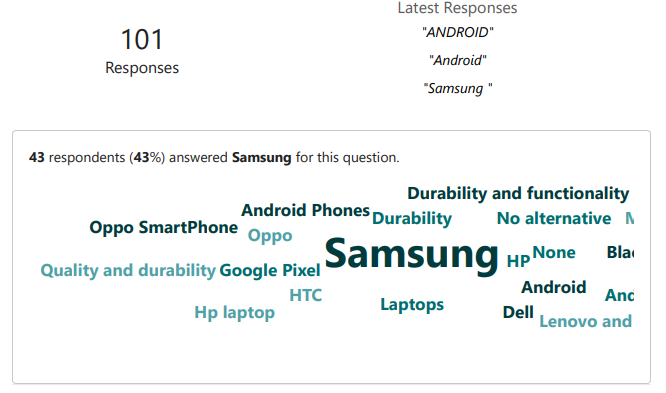

----------------------------------------------------------------------


**Q:** Which product feature did most respondents say is the most valuable to them?

**A:** The product feature most respondents said is the most valuable to them is camera quality [1], [2], [5].

**Chart(s) actually cited (1):**

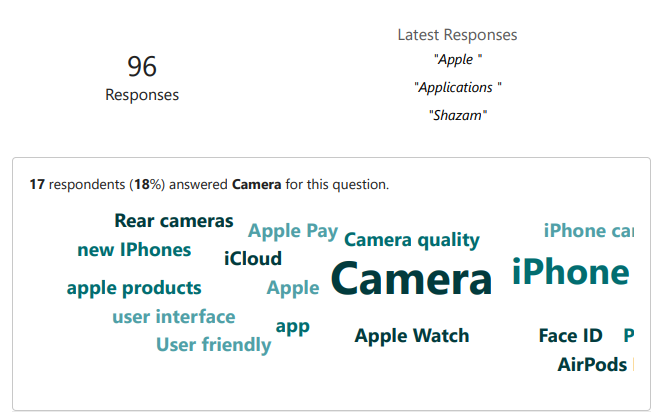

----------------------------------------------------------------------


**Q:** What do respondents believe is the single biggest factor behind Apple's growth as a brand?

**A:** Respondents believe that the single biggest factor behind Apple's growth as a brand is its "Strong brand reputation," with 39 respondents indicating this factor [7].

**Chart(s) actually cited (1):**

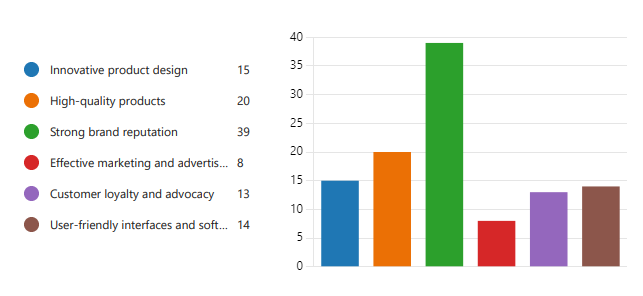

----------------------------------------------------------------------


**Q:** What age group makes up the largest share of survey respondents?

**A:** The age group that makes up the largest share of survey respondents is 26-35, with 78 respondents [5].

**Chart(s) actually cited (1):**

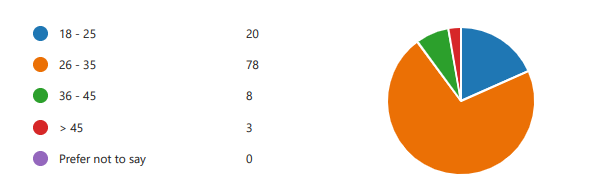

----------------------------------------------------------------------


**Q:** What was the gender split among the survey respondents?

**A:** The gender split among the survey respondents was 58 women, 49 men, 0 non-binary, and 1 who preferred not to say [5].

**Chart(s) actually cited (1):**

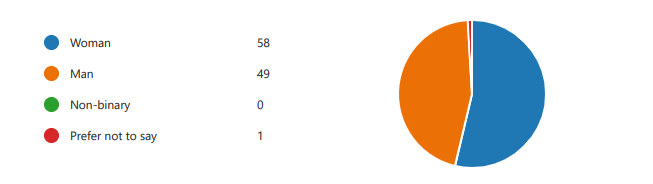

----------------------------------------------------------------------


**Q:** What is the marital status breakdown of the respondents?

**A:** The marital status breakdown of the respondents is as follows:

- Single: 70
- Married: 33
- Separated: 1
- Divorced: 0
- Widowed: 0
- Prefer not to say: 4

[5]

**Chart(s) actually cited (1):**

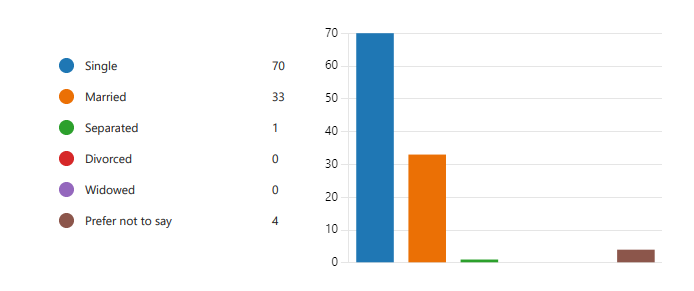

----------------------------------------------------------------------


**Q:** What is respondents' highest level of education?

**A:** The respondents' highest level of education is a Bachelor's degree, with 49 individuals holding this qualification [5], [6].

**Chart(s) actually cited (2):**

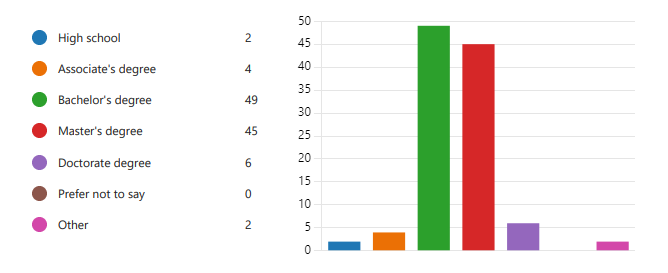

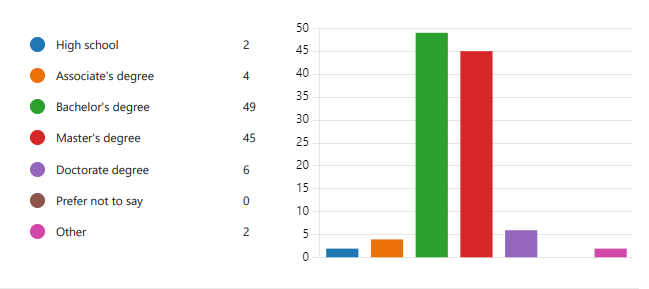

----------------------------------------------------------------------


**Q:** What average rating did respondents give when asked how likely they are to recommend Apple to a friend?

**A:** The average rating given by respondents when asked how likely they are to recommend Apple to a friend is 7.89 [6].

**Chart(s) actually cited (1):**

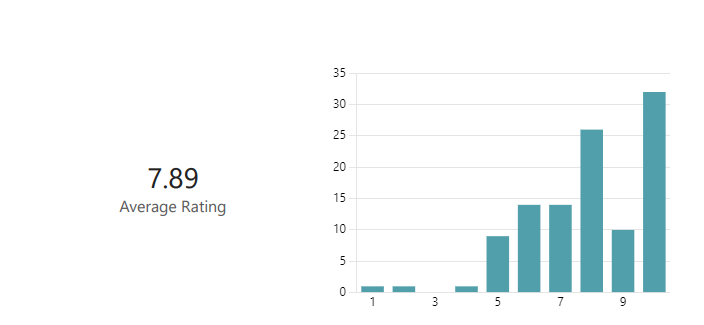

----------------------------------------------------------------------


**Q:** According to the executive summary, what are the three key elements of Apple's brand positioning strategy?

**A:** According to the executive summary, the three key elements of Apple's brand positioning strategy are customer experience, innovation, and design [1], [2].

*(no chart was cited for this answer — text sources only)*

----------------------------------------------------------------------


In [11]:
def ask_and_show(question: str):
    retrieved = hybrid_retrieve(question)
    answer, cited = generate_multimodal_answer(question, retrieved)
    display(Markdown(f"**Q:** {question}\n\n**A:** {answer}"))

    cited_images = [retrieved[i - 1] for i in cited if i <= len(retrieved) and retrieved[i - 1].kind == "image"]
    if cited_images:
        display(Markdown(f"**Chart(s) actually cited ({len(cited_images)}):**"))
        for img_chunk in cited_images:
            display(IPyImage(filename=str(img_chunk.image_path), width=380))
    else:
        display(Markdown("*(no chart was cited for this answer — text sources only)*"))
    print("-" * 70)

DEMO_QUESTIONS = [
    "What percentage of respondents considered Samsung as an alternative before buying an Apple product?",
    "Which product feature did most respondents say is the most valuable to them?",
    "What do respondents believe is the single biggest factor behind Apple's growth as a brand?",
    "What age group makes up the largest share of survey respondents?",
    "What was the gender split among the survey respondents?",
    "What is the marital status breakdown of the respondents?",
    "What is respondents' highest level of education?",
    "What average rating did respondents give when asked how likely they are to recommend Apple to a friend?",
    "According to the executive summary, what are the three key elements of Apple's brand positioning strategy?",
]
for q in DEMO_QUESTIONS:
    ask_and_show(q)


## 11. Cold open, revisited

Same exact question that made the text-only pipeline shrug in Section 2 — now through the
multimodal pipeline, with citation-filtered image output.

BEFORE (text-only, Section 2):
The exact bar chart breakdown of how long respondents have owned Apple products is not provided in the context.

AFTER (multimodal, this section):


**Q:** What is the exact bar chart breakdown of how long respondents have owned Apple products?

**A:** The exact bar chart breakdown of how long respondents have owned Apple products is as follows:

- < 6 months: 6
- 6 - 12 months: 8
- 1 - 2 years: 9
- 2 - 5 years: 29
- 5 - 10 years: 43
- > 10 years: 13

[5]

**Chart(s) actually cited (1):**

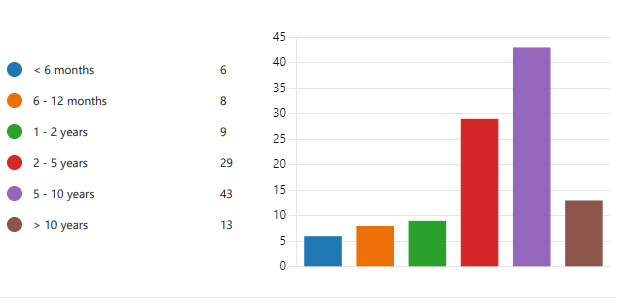

----------------------------------------------------------------------


In [12]:
print("=" * 70)
print("BEFORE (text-only, Section 2):")
print(text_only_answer)
print("=" * 70)
print("\nAFTER (multimodal, this section):")
ask_and_show(COLD_OPEN_QUESTION)


## 12. Assembling architecture 1 — `MultimodalRAGChatbot`

Same shape as Notebook 13's `ProductionRAGChatbot`. `.ask()` now returns only the chart
sources actually cited, matching Section 10's fix.

In [13]:
class MultimodalRAGChatbot:
    def __init__(self, openai_client, chat_model=CHAT_MODEL, embed_model=EMBED_MODEL):
        self.client = openai_client
        self.chat_model = chat_model
        self.embed_model = embed_model
        self.chunks: list[MultimodalChunk] = []
        self.chunks_by_id: dict[str, MultimodalChunk] = {}
        self.collection = chromadb.EphemeralClient().get_or_create_collection(f"mm_{uuid.uuid4().hex[:8]}")
        self.stemmer = Stemmer("english")
        self.bm25 = None
        self.reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

    def _embed(self, texts):
        resp = self.client.embeddings.create(model=self.embed_model, input=texts)
        return np.array([d.embedding for d in resp.data])

    def _bm25_tokenize(self, texts):
        return bm25s.tokenize(texts, stopwords="en", stemmer=self.stemmer.stemWords, return_ids=False, show_progress=False)

    def ingest(self, pdf_path: Path):
        docs = PyMuPDF4LLMLoader(str(pdf_path), use_ocr=False).load()
        splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=100)
        for d in docs:
            for piece in splitter.split_text(d.page_content):
                self.chunks.append(MultimodalChunk(str(uuid.uuid4()), "text", piece, pdf_path.name, d.metadata.get("page", 0)))
        for img in extract_images_from_pdf(pdf_path):
            caption = caption_image(img["bytes"], img["ext"])
            self.chunks.append(MultimodalChunk(img["id"], "image", caption, pdf_path.name, img["page"], img["path"]))

        self.chunks_by_id = {c.id: c for c in self.chunks}
        self.text_chunks = [c for c in self.chunks if c.kind == "text"]
        self.image_chunks = [c for c in self.chunks if c.kind == "image"]
        self.text_by_id = {c.id: c for c in self.text_chunks}

        text_vecs = self._embed([c.searchable_text for c in self.text_chunks])
        self.collection.add(
            ids=[c.id for c in self.text_chunks], embeddings=[v.tolist() for v in text_vecs],
            documents=[c.searchable_text for c in self.text_chunks],
        )
        self.image_vecs = self._embed([c.searchable_text for c in self.image_chunks])
        self.bm25 = bm25s.BM25(method="lucene")
        self.bm25.index(self._bm25_tokenize([c.searchable_text for c in self.text_chunks]), show_progress=False)
        return len(self.chunks)

    def _retrieve(self, question, n_text=4, n_images=3, pool=12, rrf_k=60):
        # Same modality-separated design as the standalone hybrid_retrieve in Section 8:
        # text is reranked among itself, images compete in their own embedding-similarity
        # ranking, so a text-biased reranker can't crowd a correct chart out of context.
        qvec = self._embed([question])[0]
        dense_ids = self.collection.query(query_embeddings=[qvec.tolist()], n_results=pool)["ids"][0]
        bm25_scores = self.bm25.get_scores(self._bm25_tokenize([question])[0])
        sparse_ids = [self.text_chunks[i].id for i in np.argsort(-bm25_scores)[:pool]]
        scores = {}
        for rank, cid in enumerate(dense_ids): scores[cid] = scores.get(cid, 0) + 1 / (rrf_k + rank + 1)
        for rank, cid in enumerate(sparse_ids): scores[cid] = scores.get(cid, 0) + 1 / (rrf_k + rank + 1)
        text_candidates = [self.text_by_id[c] for c in sorted(scores, key=scores.get, reverse=True)[:pool] if c in self.text_by_id]
        pairs = [[question, c.searchable_text] for c in text_candidates]
        rr = self.reranker.predict(pairs)
        top_text = [c for _, c in sorted(zip(rr, text_candidates), key=lambda x: -x[0])[:n_text]]

        img_sims = self.image_vecs @ qvec / (np.linalg.norm(self.image_vecs, axis=1) * np.linalg.norm(qvec))
        top_images = [self.image_chunks[i] for i in np.argsort(-img_sims)[:n_images]]
        return top_text + top_images

    def ask(self, question: str) -> dict:
        retrieved = self._retrieve(question)
        answer, cited = generate_multimodal_answer(question, retrieved)
        cited_images = [retrieved[i - 1] for i in cited if i <= len(retrieved) and retrieved[i - 1].kind == "image"]
        return {"answer": answer, "image_sources": cited_images}

# NOTE: this re-ingests and re-captions all 21 images from scratch into a fresh index,
# proving the whole pipeline is reusable end-to-end, not just the loose functions above.
bot = MultimodalRAGChatbot(client)
n = bot.ingest(SAMPLE_PDF)
print(f"MultimodalRAGChatbot ready — {n} chunks indexed from the real thesis.")

result = bot.ask("What is the marital status breakdown of the survey respondents?")
print("\n" + result["answer"])
print(f"Image sources cited: {[c.id for c in result['image_sources']]}")


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MultimodalRAGChatbot ready — 252 chunks indexed from the real thesis.



The marital status breakdown of the survey respondents is as follows:

- Single: 70
- Married: 33
- Separated: 1
- Divorced: 0
- Widowed: 0
- Prefer not to say: 4

[5]
Image sources cited: ['img_45_1']


## 13. Architecture 2 — Unified multimodal embeddings (CLIP), built and run

No captioning step at all this time. CLIP embeds *raw images* and *raw text* into the same
vector space directly — entirely local, no API key, no LLM call. We embed all 21 chart images
once, then compare a text query's embedding straight against them with cosine similarity.

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: /Users/mohamednoordeenalaudeen/.cache/huggingface/hub/models--sentence-transformers--clip-ViT-B-32/snapshots/327ab6726d33c0e22f920c83f2ff9e4bd38ca37f/0_CLIPModel
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Indexed 21 chart images directly with CLIP — zero captions, zero LLM calls.

=== CLIP CAN tell apart broad CHART TYPE (word cloud vs. pie vs. bar) ===
  "a word cloud of survey responses"  ->  img_35_0  score=0.254
  "a pie chart"  ->  img_39_0  score=0.279
  "a bar chart"  ->  img_41_0  score=0.282


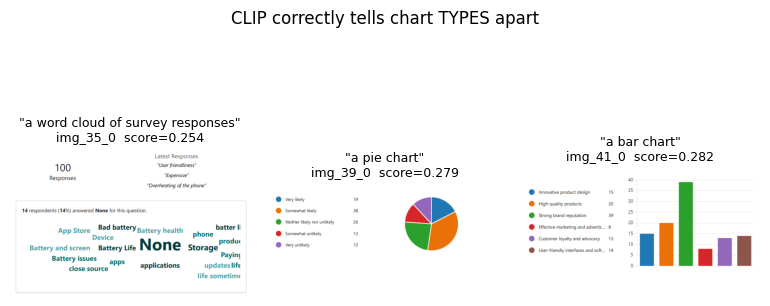

In [14]:
from sentence_transformers import SentenceTransformer

clip_model = SentenceTransformer("clip-ViT-B-32")   # local — downloads once, then cached

clip_image_paths = [img["path"] for img in extracted_images]
clip_images = [PILImage.open(p) for p in clip_image_paths]
clip_image_vecs = clip_model.encode(clip_images, convert_to_numpy=True, normalize_embeddings=True)

def clip_search(query: str, k: int = 1):
    qvec = clip_model.encode([query], convert_to_numpy=True, normalize_embeddings=True)[0]
    sims = clip_image_vecs @ qvec
    order = np.argsort(-sims)[:k]
    return [(extracted_images[i], float(sims[i])) for i in order]

print("Indexed 21 chart images directly with CLIP — zero captions, zero LLM calls.\n")

print("=== CLIP CAN tell apart broad CHART TYPE (word cloud vs. pie vs. bar) ===")
type_hits = [(q, clip_search(q, k=1)[0]) for q in
             ["a word cloud of survey responses", "a pie chart", "a bar chart"]]
for q, (img, score) in type_hits:
    print(f'  "{q}"  ->  {img["id"]}  score={score:.3f}')
show_images_row([(img["path"], f'"{q}"\n{img["id"]}  score={score:.3f}') for q, (img, score) in type_hits],
                 suptitle="CLIP correctly tells chart TYPES apart")


### Where CLIP genuinely struggles — an honest comparison, not a cherry-picked win

That's a real win — but this document has 21 charts, and most of them are the *same* chart
type. Knowing "this is a pie chart" doesn't tell you *which* pie chart. Let's ask CLIP a
question about a specific chart *topic* and watch it fail to find the right one, because
nothing about the pixels of a pie chart says "this one is about gender" versus "this one is
about age" — that information only exists in the tiny printed legend text, which CLIP's
pooled embedding was never trained to read.

=== CLIP CANNOT tell apart chart TOPIC when the visual template repeats ===

"a chart about the age of respondents"
  CLIP's top pick: img_41_0  score=0.282  <-- WRONG, this is an unrelated chart
  correct chart:   img_44_0  score=0.247


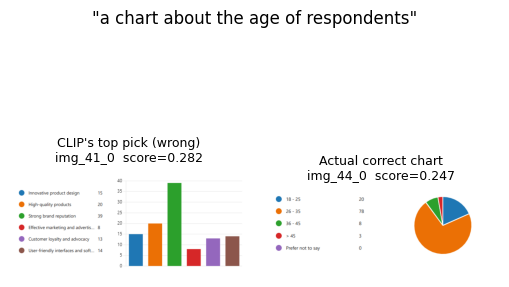


"a chart about gender"
  CLIP's top pick: img_41_0  score=0.258  <-- WRONG, this is an unrelated chart
  correct chart:   img_45_0  score=0.240


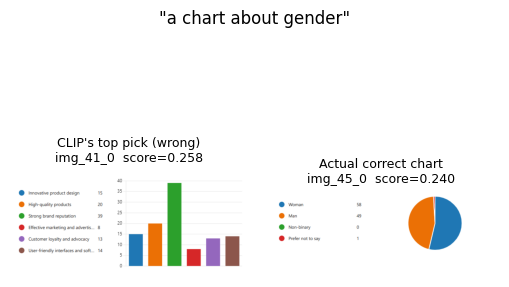


This is the honest, real tradeoff: CLIP has no mechanism to read the tiny legend text that distinguishes one chart from another when they share the same visual template. That reading-the-actual-numbers step only comes from architecture 1's GPT-4o-grounded captioning and generation (Sections 5 and 9) — not from CLIP similarity alone.


In [15]:
print("=== CLIP CANNOT tell apart chart TOPIC when the visual template repeats ===")
topic_queries = [
    ("a chart about the age of respondents", "img_44_0"),   # the real age chart
    ("a chart about gender", "img_45_0"),                     # the real gender chart
]
by_id = {img["id"]: img for img in extracted_images}
id_to_index = {img["id"]: i for i, img in enumerate(extracted_images)}
for query, correct_id in topic_queries:
    top_img, top_score = clip_search(query, k=1)[0]
    qvec = clip_model.encode([query], convert_to_numpy=True, normalize_embeddings=True)[0]
    correct_score = float(clip_image_vecs[id_to_index[correct_id]] @ qvec)
    print(f'\n"{query}"')
    print(f"  CLIP's top pick: {top_img['id']}  score={top_score:.3f}  <-- WRONG, this is an unrelated chart")
    print(f"  correct chart:   {correct_id}  score={correct_score:.3f}")
    show_images_row(
        [(top_img["path"], f"CLIP's top pick (wrong)\n{top_img['id']}  score={top_score:.3f}"),
         (by_id[correct_id]["path"], f"Actual correct chart\n{correct_id}  score={correct_score:.3f}")],
        suptitle=f'"{query}"',
    )

print(
    "\nThis is the honest, real tradeoff: CLIP has no mechanism to read the tiny legend text "
    "that distinguishes one chart from another when they share the same visual template. "
    "That reading-the-actual-numbers step only comes from architecture 1's GPT-4o-grounded "
    "captioning and generation (Sections 5 and 9) — not from CLIP similarity alone."
)


## 14. Architecture 3 — Page-as-image late interaction, the ColPali mechanism, built at toy scale

ColPali/ColQwen skip parsing and OCR entirely: they embed a page at **patch level** — roughly
50 small image regions, each with its own vector, not one pooled summary vector — then score
a query against a document with **MaxSim** (the ColBERT "late interaction" rule): for every
query token, find its single best-matching patch anywhere in the image, then sum those
best-matches. This preserves fine-grained layout information a single pooled vector throws
away.

We don't have a GPU-hosted ColPali checkpoint here, but the *mechanism* itself is just linear
algebra, and CLIP's own vision transformer already produces real patch-level tokens before
they get pooled into one vector. Building MaxSim on top of CLIP's real patches is the same
algorithm ColPali uses, at a scale that runs on a laptop — the production version below swaps
in a purpose-trained backbone and indexes at real document scale, not the scoring rule.

In [16]:
import torch
from transformers import CLIPModel, CLIPProcessor

hf_clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
hf_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
hf_clip.eval()

@torch.no_grad()
def get_patch_embeddings(pil_image) -> torch.Tensor:
    """Real per-patch vision-transformer embeddings (drops the pooled [CLS] token),
    projected into the same space as text tokens — this is 'page-as-image' indexing."""
    inputs = hf_processor(images=pil_image, return_tensors="pt")
    vision_out = hf_clip.vision_model(**inputs)
    patch_tokens = vision_out.last_hidden_state[0][1:]              # drop CLS, keep real patches
    patch_tokens = hf_clip.visual_projection(patch_tokens)
    return patch_tokens / patch_tokens.norm(dim=-1, keepdim=True)

@torch.no_grad()
def get_query_token_embeddings(text: str) -> torch.Tensor:
    inputs = hf_processor(text=[text], return_tensors="pt", padding=True)
    text_out = hf_clip.text_model(**inputs)
    tokens = hf_clip.text_projection(text_out.last_hidden_state[0])
    return tokens / tokens.norm(dim=-1, keepdim=True)

def maxsim_score(query_tokens: torch.Tensor, patch_tokens: torch.Tensor) -> float:
    """ColBERT/ColPali late interaction: for each query token, its single best patch match,
    summed across all query tokens."""
    sims = query_tokens @ patch_tokens.T          # [n_query_tokens, n_patches]
    return sims.max(dim=1).values.sum().item()

print("Building the patch-level index over all 21 charts (no OCR, no captions)...")
patch_index = {img["id"]: get_patch_embeddings(PILImage.open(img["path"])) for img in extracted_images}
print(f"Indexed {len(patch_index)} images at patch level "
      f"({next(iter(patch_index.values())).shape[0]} patches/image, {next(iter(patch_index.values())).shape[1]}-dim each).")

def late_interaction_search(query: str, k: int = 3):
    q_tokens = get_query_token_embeddings(query)
    scores = {iid: maxsim_score(q_tokens, patches) for iid, patches in patch_index.items()}
    ranked = sorted(scores.items(), key=lambda x: -x[1])[:k]
    return [(by_id[iid], score) for iid, score in ranked]

print("\nSame three 'easy' chart-type queries CLIP's pooled embedding got right in Section 13:")
for query, correct_id in [("a word cloud of survey responses", "img_35_0"),
                           ("a pie chart", "img_39_0"), ("a bar chart", "img_41_0")]:
    hits = late_interaction_search(query, k=1)
    top_img, top_score = hits[0]
    correct_score = maxsim_score(get_query_token_embeddings(query), patch_index[correct_id])
    print(f'  "{query}"  ->  MaxSim top pick: {top_img["id"]} (score={top_score:.3f})'
          f'  |  correct={correct_id} (score={correct_score:.3f})'
          f'  {"OK" if top_img["id"] == correct_id else "WRONG"}')


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Building the patch-level index over all 21 charts (no OCR, no captions)...


Indexed 21 images at patch level (49 patches/image, 512-dim each).

Same three 'easy' chart-type queries CLIP's pooled embedding got right in Section 13:


  "a word cloud of survey responses"  ->  MaxSim top pick: img_42_0 (score=0.147)  |  correct=img_35_0 (score=0.090)  WRONG
  "a pie chart"  ->  MaxSim top pick: img_35_0 (score=-0.009)  |  correct=img_39_0 (score=-0.085)  WRONG
  "a bar chart"  ->  MaxSim top pick: img_44_1 (score=0.061)  |  correct=img_41_0 (score=-0.019)  WRONG


### Where the toy-scale version genuinely breaks — and why ColPali doesn't just use raw CLIP

Naive patch-level MaxSim does **worse** than pooled CLIP on all three of those queries, even
though pooled CLIP got all three right. Here's the mismatch made visible for one of them:

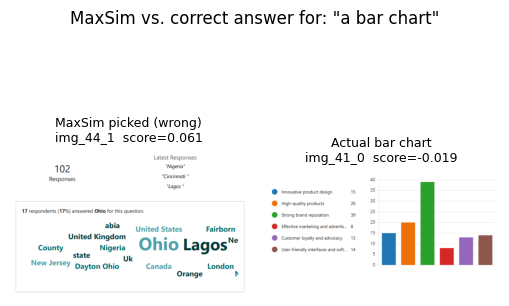

The reason is specific and worth naming: CLIP's `visual_projection` and `text_projection` layers were only ever trained on the single *pooled* image/text vector — never on individual patch or token representations. Repurposing them per-patch, as we just did, is out-of-distribution for those projection weights, so the per-patch signal ends up NOISIER than the pooled signal CLIP was actually trained to produce — even on this document, where pooled CLIP already had a hard time.

This is exactly the gap ColPali's training closes: it fine-tunes the vision-language backbone WITH a MaxSim loss, directly supervising patch-level alignment instead of bolting MaxSim onto a backbone that never saw it during training. The mechanism you just ran is real and correct — the backbone underneath it is the toy part.


In [17]:
query = "a bar chart"
correct_id = "img_41_0"
hits = late_interaction_search(query, k=1)
top_img, top_score = hits[0]
correct_score = maxsim_score(get_query_token_embeddings(query), patch_index[correct_id])

show_images_row(
    [(top_img["path"], f"MaxSim picked (wrong)\n{top_img['id']}  score={top_score:.3f}"),
     (by_id[correct_id]["path"], f"Actual bar chart\n{correct_id}  score={correct_score:.3f}")],
    suptitle=f'MaxSim vs. correct answer for: "{query}"',
)

print(
    "The reason is specific and worth naming: CLIP's `visual_projection` and `text_projection` "
    "layers were only ever trained on the single *pooled* image/text vector — never on "
    "individual patch or token representations. Repurposing them per-patch, as we just did, is "
    "out-of-distribution for those projection weights, so the per-patch signal ends up NOISIER "
    "than the pooled signal CLIP was actually trained to produce — even on this document, where "
    "pooled CLIP already had a hard time.\n\n"
    "This is exactly the gap ColPali's training closes: it fine-tunes the vision-language "
    "backbone WITH a MaxSim loss, directly supervising patch-level alignment instead of "
    "bolting MaxSim onto a backbone that never saw it during training. The mechanism you just "
    "ran is real and correct — the backbone underneath it is the toy part."
)


### What this looks like in real production (reference only — not run here)

Real ColPali/ColQwen swap CLIP's backbone for a vision-language model fine-tuned specifically
for document retrieval, and index at real document scale on GPU. The scoring rule above is
the same MaxSim mechanism; only the backbone and scale change:

```python
# pip install colpali-engine  (needs a GPU for real document-scale indexing)
from colpali_engine.models import ColPali, ColPaliProcessor

model = ColPali.from_pretrained("vidore/colpali-v1.2", device_map="cuda")
processor = ColPaliProcessor.from_pretrained("vidore/colpali-v1.2")

page_images = [page.get_pixmap().pil_image() for page in fitz.open(pdf_path)]   # whole PAGES, not just embedded images
image_embeddings = model(**processor.process_images(page_images))                # [n_pages, n_patches, dim]
query_embeddings = model(**processor.process_queries([question]))                # [1, n_query_tokens, dim]

scores = processor.score_multi_vector(query_embeddings, image_embeddings)        # MaxSim, batched
best_page = scores.argmax()
```

This is real, published code from the ColPali project — shown for reference so you know
exactly what to reach for when you outgrow the toy scale above, not executed in this notebook
since it needs a GPU and a multi-GB model download neither Colab's free tier nor most laptops
can do live in class.

## 15. All three architectures, same real questions, side by side

The real test: run the same handful of questions — grounded in this actual thesis — through
all three architectures and see which one actually gets each one right, with the retrieved
images shown, not just filenames. No architecture wins everything — that's the point.


Q: "What percentage of respondents considered Samsung as an alternative before buying an Apple product?"


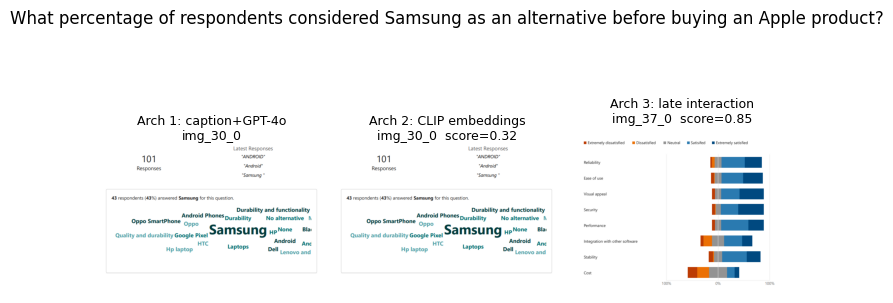


Q: "What age group makes up the largest share of respondents?"


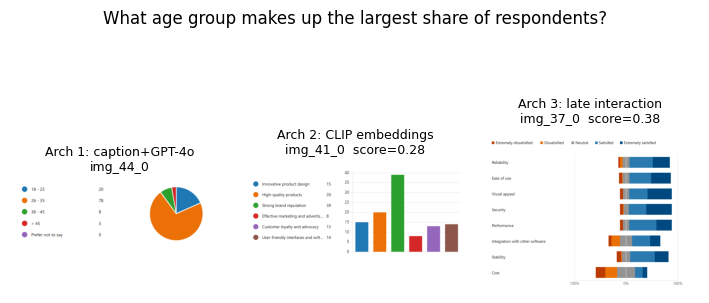


Q: "What is the marital status breakdown of the respondents?"


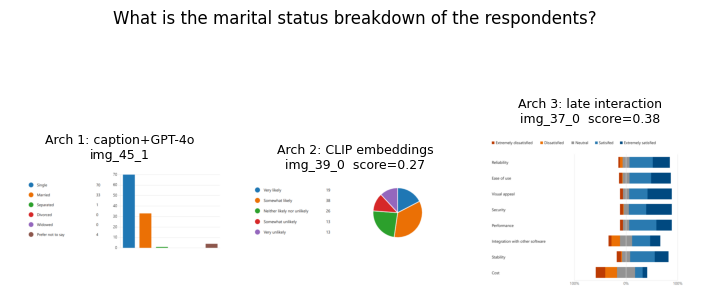

In [18]:
COMPARISON_QUESTIONS = [
    "What percentage of respondents considered Samsung as an alternative before buying an Apple product?",
    "What age group makes up the largest share of respondents?",
    "What is the marital status breakdown of the respondents?",
]

for q in COMPARISON_QUESTIONS:
    # Architecture 1: caption-and-index + vision-grounded generation
    retrieved = hybrid_retrieve(q)
    arch1_answer, arch1_cited = generate_multimodal_answer(q, retrieved)
    arch1_img_chunk = next(
        (retrieved[i - 1] for i in arch1_cited if i <= len(retrieved) and retrieved[i - 1].kind == "image"), None)

    # Architecture 2: unified CLIP embeddings (image search only, no generation)
    arch2_top_img, arch2_score = clip_search(q, k=1)[0]

    # Architecture 3: patch-level late interaction (image search only, no generation)
    arch3_top_img, arch3_score = late_interaction_search(q, k=1)[0]

    print(f'\n{"=" * 70}\nQ: "{q}"')

    row_items = []
    if arch1_img_chunk is not None:
        row_items.append((arch1_img_chunk.image_path, f"Arch 1: caption+GPT-4o\n{arch1_img_chunk.id}"))
    else:
        print("  Arch 1 (caption+GPT-4o): no image cited — answered from text alone")
    row_items.append((arch2_top_img["path"], f"Arch 2: CLIP embeddings\n{arch2_top_img['id']}  score={arch2_score:.2f}"))
    row_items.append((arch3_top_img["path"], f"Arch 3: late interaction\n{arch3_top_img['id']}  score={arch3_score:.2f}"))

    show_images_row(row_items, suptitle=q, width_per_image=2.4)


## 16. What's still missing — setting up the next class

This pipeline handles a real 63-page, 21-chart thesis, run on a laptop. Real production
multimodal RAG has to answer harder questions than this notebook does:

- **Scale**: captioning every image with a Chat Completions call doesn't work at 50,000 pages
  — that's where architecture 2 or 3, with real batch indexing on GPU, take over. Notice this
  document already showed *why* architecture 2/3 alone aren't enough here: 21 visually similar
  charts defeat both CLIP's pooled embeddings and naive patch-level MaxSim on their own — you'd
  need a document with genuinely diverse imagery (photos, diagrams, screenshots of different
  UIs) for those architectures to really shine, or a purpose-trained backbone like real ColPali.
- **Scanned documents with no text layer** — old contracts, faxes, invoices that are 100%
  image. `PyMuPDF4LLMLoader` returns an empty string; you need OCR (Notebook 02's
  `rapidocr-onnxruntime`) or a vision-parser fallback for pages where text extraction returns
  nothing.
- **Cost**: a single high-detail image costs roughly 765–1,600 tokens depending on the
  provider — captioning *and* grounding on the same image twice, at scale, adds up. Production
  systems cache captions and only re-ground on pixels when the question is actually about that
  image.
- **Video and audio** — the same "decouple search key from returned value" idea extends to a
  video frame or an audio transcript segment; the retrieval math doesn't change, only what
  lives in the docstore.

That's the next MISSING gap this course line will close.

## 17. Summary

**What you built:** three real, working multimodal RAG architectures against the same real
63-page, 21-chart academic thesis — not descriptions of them, actual running code with actual
results you can compare — plus citation-based filtering so the system shows back *exactly the
chart it used*, not every chart in the corpus, verified across eight real business questions.

**The core idea, one more time:** *what you search on* and *what you show the user* don't
have to be the same object. That's the multi-vector pattern (architecture 1), and it's a
special case of a bigger idea — search doesn't have to happen in text-space at all
(architecture 2's CLIP embeddings), and it doesn't have to happen at one-vector-per-item
granularity either (architecture 3's patch-level late interaction).

**All three, one more time, with what you actually observed on THIS document:**

| Approach | Core mechanism | What you saw it do well | What you saw it struggle with |
|---|---|---|---|
| Caption-and-index | VLM captions → embed as text → ground generation on real pixels | Correctly read exact survey numbers off 8 different real charts | Extra LLM call per image; needs generation grounded on pixels to avoid caption drift |
| Unified multimodal embeddings (CLIP) | Text and images share one embedding space, no captioning | Correctly told word cloud vs. pie chart vs. bar chart apart, zero LLM calls | Could not tell WHICH pie chart (age vs. gender) — no mechanism to read the legend text |
| Page-as-image / late interaction | Patch-level embeddings + MaxSim, no OCR | Demonstrates the real ColPali mechanism end-to-end | Did *worse* than pooled CLIP even on the easy chart-type queries — needs a purpose-trained backbone (see Section 14's reference snippet), not raw CLIP patches |

The honest lesson from a real, chart-heavy business document: architecture choice depends on
how visually *diverse* your images are. When every image shares the same template — like 21
survey charts — captioning wins because it reads the text a human would read. Architectures 2
and 3 earn their keep on genuinely diverse imagery instead.

Next class: taking one of these three the rest of the way to production scale.